In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import shap

import warnings
warnings.filterwarnings('ignore')

# 1. Data Discovery

Load Dataset

In [12]:
df_events = pd.read_json('../data/stream_events.jsonl', lines=True)
df_events.head()

,event_id,event_time,user_id,dept,role,clearance,employee_status,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-06-09 19:26:54,U0137,Operations,admin,confidential,active,server,10.10.3.166,cust_db,database,restricted,upload,success,18209,193,95,0,normal
1,EVT0000002,2026-06-09 19:27:04,U0067,Data Science,intern,restricted,active,server,10.10.13.73,public_web,web,public,read,success,36452,280,127,1,normal
2,EVT0000003,2026-06-09 19:27:14,U0121,Sales,admin,internal,active,laptop,10.10.8.168,cust_db,database,restricted,query,success,196646,508,143,25,normal
3,EVT0000004,2026-06-09 19:27:24,U0064,Sales,manager,restricted,active,mobile,10.10.16.173,data_lake,storage,restricted,download,success,53304,223,104,4,normal
4,EVT0000005,2026-06-09 19:27:34,U0095,Operations,analyst,confidential,active,vpn_gateway,10.10.6.248,crm,saas,confidential,query,success,157538,11252,109,4,normal


In [13]:
df_users = pd.read_csv('../data/users.csv')
df_users.head()

,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active


In [14]:
df_assets = pd.read_csv('../data/assets.csv')
df_assets.head()

,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal


schema, jumlah baris, missing value, duplicate event_id

In [15]:
print("df_events columns:\n", ", ".join(df_events.columns))
print("\ndf_users columns:\n", ", ".join(df_users.columns))
print("\ndf_assets columns:\n", ", ".join(df_assets.columns))

df_events columns:
 event_id, event_time, user_id, dept, role, clearance, employee_status, device_type, source_ip, asset_id, asset_type, data_classification, action, status, bytes_out, records_accessed, latency_ms, risk_score, label

df_users columns:
 user_id, employee_id, dept, role, clearance, location, status

df_assets columns:
 asset_id, asset_type, data_classification


In [16]:
print("df_events rows:", len(df_events))
print("df_users rows:", len(df_users))
print("df_assets rows:", len(df_assets))

df_events rows: 100000
df_users rows: 150
df_assets rows: 8


In [17]:
print("missing value")

print("\n[df_events]:")
print(df_events.isnull().sum()[df_events.isnull().sum() > 0] if df_events.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_users]:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0] if df_users.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_assets]:")
print(df_assets.isnull().sum()[df_assets.isnull().sum() > 0] if df_assets.isnull().sum().sum() > 0 else "Tidak ada missing value")

missing value

[df_events]:
Tidak ada missing value

[df_users]:
Tidak ada missing value

[df_assets]:
Tidak ada missing value


In [18]:
duplicate_count = df_events.duplicated(subset=['event_id']).sum()
print(f"Jumlah baris dengan event_id duplikat: {duplicate_count}")

Jumlah baris dengan event_id duplikat: 0


distribusi action, status, data_classification

=== DISTRIBUSI KOLOM: ACTION ===
                   Count  Percentage (%)
action                                  
read               25675           25.67
login              22678           22.68
query              18532           18.53
download           10306           10.31
logout              8293            8.29
upload              6182            6.18
schema_discovery    5255            5.26
delete              2049            2.05
permission_change   1030            1.03


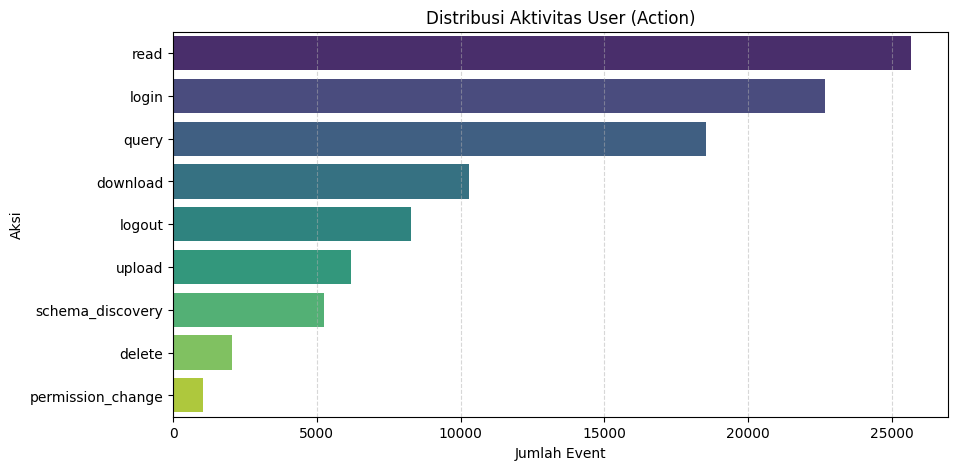

In [19]:
print("=== DISTRIBUSI KOLOM: ACTION ===")
# 1. Tampilkan Tabel Ringkas
df_action = df_events['action'].value_counts().to_frame(name='Count')
df_action['Percentage (%)'] = (df_events['action'].value_counts(normalize=True) * 100).round(2)
print(df_action)

# 2. Visualisasi Bar Plot Horizontal (Cocok untuk kategori yang banyak)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_events, y='action', order=df_events['action'].value_counts().index, palette='viridis')
plt.title('Distribusi Aktivitas User (Action)')
plt.xlabel('Jumlah Event')
plt.ylabel('Aksi')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

=== DISTRIBUSI KOLOM: STATUS ===
         Count  Percentage (%)
status                        
success  89946           89.95
failed   10054           10.05


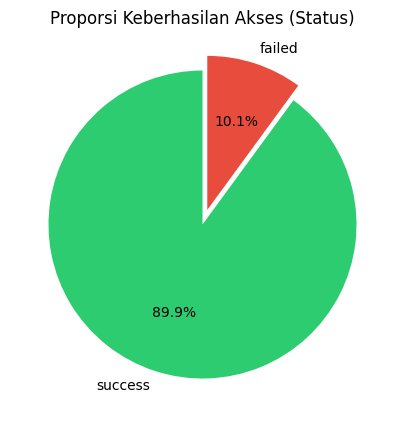

In [20]:
print("=== DISTRIBUSI KOLOM: STATUS ===")
# 1. Tampilkan Tabel Ringkas
df_status = df_events['status'].value_counts().to_frame(name='Count')
df_status['Percentage (%)'] = (df_events['status'].value_counts(normalize=True) * 100).round(2)
print(df_status)

# 2. Visualisasi Pie Chart (Cocok untuk kategori sedikit/biner)
plt.figure(figsize=(5, 5))
df_events['status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
plt.title('Proporsi Keberhasilan Akses (Status)')
plt.ylabel('') # Menghilangkan label y otomatis
plt.show()

=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===
                     Count  Percentage (%)
data_classification                       
internal             37631           37.63
restricted           25011           25.01
confidential         24986           24.99
public               12372           12.37


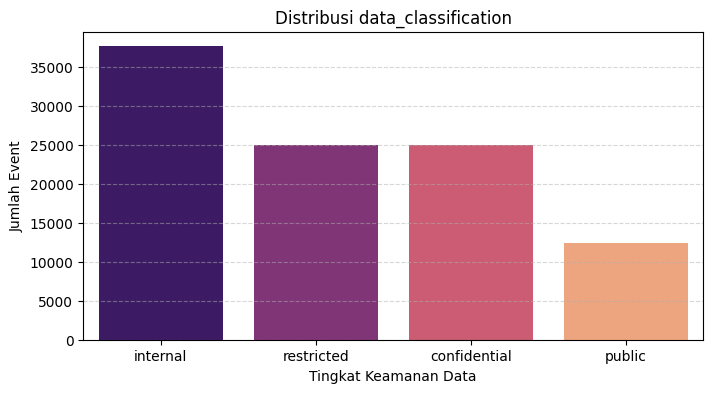

In [21]:
print("=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===")
# 1. Tampilkan Tabel Ringkas
df_class = df_events['data_classification'].value_counts().to_frame(name='Count')
df_class['Percentage (%)'] = (df_events['data_classification'].value_counts(normalize=True) * 100).round(2)
print(df_class)

# 2. Visualisasi Bar Plot Vertikal
plt.figure(figsize=(8, 4))
sns.countplot(data=df_events, x='data_classification', order=df_events['data_classification'].value_counts().index, palette='magma')
plt.title('Distribusi data_classification')
plt.xlabel('Tingkat Keamanan Data')
plt.ylabel('Jumlah Event')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

top 5 user dan access

In [22]:
top_users = df_events['user_id'].value_counts().head(5).to_frame(name='Jumlah Event')
top_users['Persentase (%)'] = (df_events['user_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_users)

         Jumlah Event  Persentase (%)
user_id                              
U0136             734            0.73
U0002             721            0.72
U0037             718            0.72
U0104             717            0.72
U0135             716            0.72


In [23]:
top_assets = df_events['asset_id'].value_counts().head(5).to_frame(name='Jumlah Akses')
top_assets['Persentase (%)'] = (df_events['asset_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_assets)

              Jumlah Akses  Persentase (%)
asset_id                                  
payroll              12633           12.63
git_repo             12632           12.63
bi_dashboard         12577           12.58
data_lake            12521           12.52
cust_db              12490           12.49


Data Dictionary ditulis di laporan

In [24]:
# Menampilkan tipe data dan jumlah baris non-null untuk memastikan kesesuaian skema
df_events[['event_id', 'event_time', 'user_id', 'source_ip', 'asset_id', 
           'data_classification', 'action', 'bytes_out', 'risk_score', 'label']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   event_id             100000 non-null  object        
 1   event_time           100000 non-null  datetime64[ns]
 2   user_id              100000 non-null  object        
 3   source_ip            100000 non-null  object        
 4   asset_id             100000 non-null  object        
 5   data_classification  100000 non-null  object        
 6   action               100000 non-null  object        
 7   bytes_out            100000 non-null  int64         
 8   risk_score           100000 non-null  int64         
 9   label                100000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 7.6+ MB


# 2. Data Science

Feature Engineering

In [25]:
df_events.columns

Index(['event_id', 'event_time', 'user_id', 'dept', 'role', 'clearance',
       'employee_status', 'device_type', 'source_ip', 'asset_id', 'asset_type',
       'data_classification', 'action', 'status', 'bytes_out',
       'records_accessed', 'latency_ms', 'risk_score', 'label'],
      dtype='object')

In [26]:
# Wajib diurutkan berdasarkan user_id dan waktu agar fitur 'rolling' tidak membaca masa depan
df_events = df_events.sort_values(by=['user_id', 'event_time'])

# Merge untuk mendapatkan konteks dari df_users
# ubah nama kolom 'status' dari df_users menjadi 'employee_status' agar tidak bentrok dengan kolom 'status' di df_events
# df_users_subset = df_users[['user_id', 'clearance', 'status']].rename(columns={'status': 'employee_status'})
# df_events = df_events.merge(df_users_subset, on='user_id', how='left')
df_events.head()

,event_id,event_time,user_id,dept,role,clearance,employee_status,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
155,EVT0000156,2026-06-09 19:52:44,U0001,Data Science,analyst,public,active,laptop,10.10.3.140,data_lake,storage,restricted,query,failed,124108,259,127,32,normal
237,EVT0000238,2026-06-09 20:06:24,U0001,Data Science,analyst,public,active,mobile,10.10.12.100,cust_db,database,restricted,upload,failed,95295,199,120,25,normal
324,EVT0000325,2026-06-09 20:20:54,U0001,Data Science,analyst,public,active,server,10.10.17.145,payroll,database,confidential,download,success,149334,306,110,30,normal
387,EVT0000388,2026-06-09 20:31:24,U0001,Data Science,analyst,public,active,vpn_gateway,10.10.13.105,crm,saas,confidential,login,success,71807,8975,149,26,normal
721,EVT0000722,2026-06-09 21:27:04,U0001,Data Science,analyst,public,active,server,10.10.18.231,ticketing,saas,internal,login,success,110814,283,121,6,normal


In [27]:
## Fitur Kontekstual (Rule-Based Context)

# A. Pelanggaran Akses (Clearance rendah vs Aset Tinggi)
df_events['is_clearance_violation'] = (
    df_events['clearance'].isin(['public', 'internal']) & 
    df_events['data_classification'].isin(['restricted', 'confidential'])
).astype(int)

# B. Akses oleh akun yang sudah non-aktif (Terminated / Resign)
df_events['is_terminated_access'] = (df_events['employee_status'] == 'terminated').astype(int)

# C. Aksi berisiko tinggi
df_events['is_high_risk_action'] = df_events['action'].isin(['delete', 'permission_change']).astype(int)
df_events[['event_time', 'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action']].head()

,event_time,is_clearance_violation,is_terminated_access,is_high_risk_action
155,2026-06-09 19:52:44,1,0,0
237,2026-06-09 20:06:24,1,0,0
324,2026-06-09 20:20:54,1,0,0
387,2026-06-09 20:31:24,1,0,0
721,2026-06-09 21:27:04,0,0,0


In [28]:
## Fitur Ekstraksi Waktu (Temporal Features)
# asumsikan jam kerja normal adalah 08:00 hingga 18:00
df_events['is_outside_working_hours'] = ((df_events['event_time'].dt.hour < 8) | (df_events['event_time'].dt.hour > 18)).astype(int)

# Deteksi akses di akhir pekan (Sabtu=5, Minggu=6)
df_events['is_weekend'] = (df_events['event_time'].dt.dayofweek >= 5).astype(int)

df_events[['event_time', 'is_outside_working_hours', 'is_weekend']].head()

,event_time,is_outside_working_hours,is_weekend
155,2026-06-09 19:52:44,1,0
237,2026-06-09 20:06:24,1,0
324,2026-06-09 20:20:54,1,0
387,2026-06-09 20:31:24,1,0
721,2026-06-09 21:27:04,1,0


In [29]:
## Fitur Jendela Waktu (Rolling Window / Stateful)
# Pindahkan event_time ke index sementara agar fungsi .rolling() dari Pandas bisa menggunakan parameter waktu ('1h')
df_events = df_events.set_index('event_time')

# Kolom bantuan (flag) untuk menghitung gagal login
df_events['is_failed_login'] = ((df_events['action'] == 'login') & (df_events['status'] == 'failed')).astype(int)

# A. Akumulasi Bytes Out dalam 1 jam terakhir
df_events['rolling_bytes_1h'] = df_events.groupby('user_id')['bytes_out'].rolling('1h').sum().reset_index(level=0, drop=True)

# B. Jumlah gagal login dalam 1 jam terakhir
df_events['rolling_failed_logins_1h'] = df_events.groupby('user_id')['is_failed_login'].rolling('1h').sum().reset_index(level=0, drop=True)

# C. Jumlah aktivitas (Event Count) dalam 1 jam terakhir
df_events['event_count_1h'] = df_events.groupby('user_id')['action'].rolling('1h').count().reset_index(level=0, drop=True)

# Kembalikan index menjadi kolom biasa dan buang kolom bantuan
df_events = df_events.reset_index().drop(columns=['is_failed_login'])

df_events[['event_time', 'user_id', 'rolling_bytes_1h', 'rolling_failed_logins_1h', 'event_count_1h']].head()

,event_time,user_id,rolling_bytes_1h,rolling_failed_logins_1h,event_count_1h
0,2026-06-09 19:52:44,U0001,124108.0,0.0,1.0
1,2026-06-09 20:06:24,U0001,219403.0,0.0,2.0
2,2026-06-09 20:20:54,U0001,368737.0,0.0,3.0
3,2026-06-09 20:31:24,U0001,440544.0,0.0,4.0
4,2026-06-09 21:27:04,U0001,182621.0,0.0,2.0


In [30]:
# Anomali = 1, Normal = 0
df_events['target'] = (df_events['label'] != 'normal').astype(int)

In [31]:
print(f"Dimensi Data Baru: {df_events.shape}")

Dimensi Data Baru: (100000, 28)


EDA

In [32]:
features = [
    'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action',
    'is_outside_working_hours', 'is_weekend', 'rolling_bytes_1h',
    'rolling_failed_logins_1h', 'event_count_1h', 'target'
]

In [33]:
print(df_events[features].describe())

       is_clearance_violation  is_terminated_access  is_high_risk_action  \
count           100000.000000         100000.000000        100000.000000   
mean                 0.278670              0.053860             0.030790   
std                  0.448347              0.225742             0.172749   
min                  0.000000              0.000000             0.000000   
25%                  0.000000              0.000000             0.000000   
50%                  0.000000              0.000000             0.000000   
75%                  1.000000              0.000000             0.000000   
max                  1.000000              1.000000             1.000000   

       is_outside_working_hours     is_weekend  rolling_bytes_1h  \
count             100000.000000  100000.000000      1.000000e+05   
mean                   0.559990       0.292410      2.991412e+05   
std                    0.496391       0.454872      1.913082e+06   
min                    0.000000       0.000

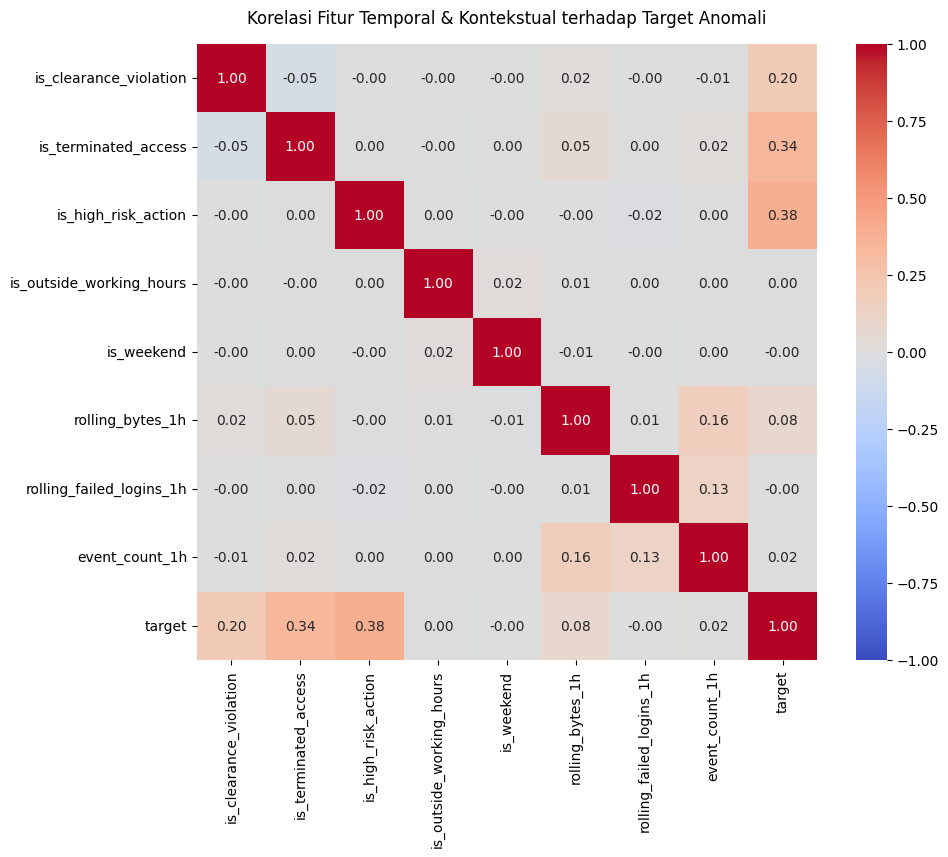

In [34]:
plt.figure(figsize=(10, 8))
# Hitung korelasi pearson
corr_matrix = df_events[features].corr()

# Tampilkan Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Fitur Temporal & Kontekstual terhadap Target Anomali', pad=15, fontsize=12)
plt.show()

Nilai korelasi pearson yang rendah (di bawah 0.2) membuktikan bahwa pendeteksian serangan siber bukanlah masalah yang bisa dipecahkan dengan regresi linear sederhana. Anomali terbentuk dari kombinasi kondisi (misalnya: user terminated + akses di luar jam kerja), bukan dari kenaikan satu variabel secara proporsional.

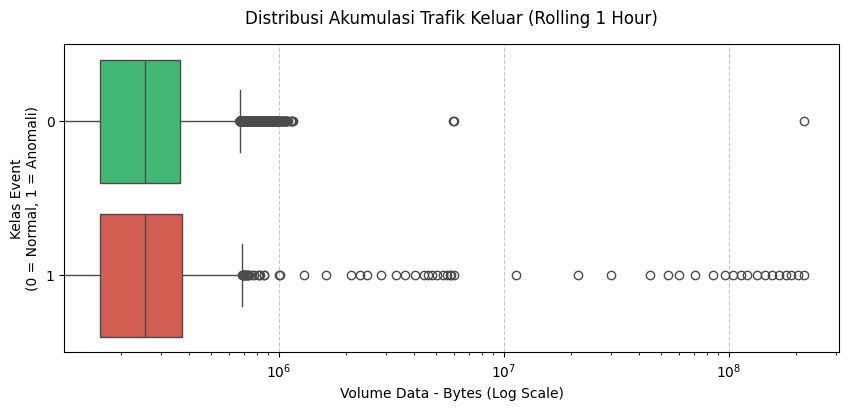

In [35]:
plt.figure(figsize=(10, 4))
# Menggunakan skala log untuk menyeimbangkan visualisasi
sns.boxplot(
    data=df_events, 
    x='rolling_bytes_1h', 
    y=df_events['target'].astype(str), 
    palette=['#2ecc71', '#e74c3c']
)

plt.xscale('log')
plt.title('Distribusi Akumulasi Trafik Keluar (Rolling 1 Hour)', pad=15)
plt.xlabel('Volume Data - Bytes (Log Scale)')
plt.ylabel('Kelas Event\n(0 = Normal, 1 = Anomali)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Sebaran Kelas Normal (0): Aktivitas pengguna normal sangat padat dan terpusat di bawah ambang batas sekitar 1 MB per jam.Ekor Panjang Kelas Anomali (1): Terdapat sebaran outlier yang sangat panjang dan masif pada kelas anomali. Titik-titik ini memanjang dari 1 MB hingga mencapai lebih dari 200 MB dalam rentang waktu 1 jam.

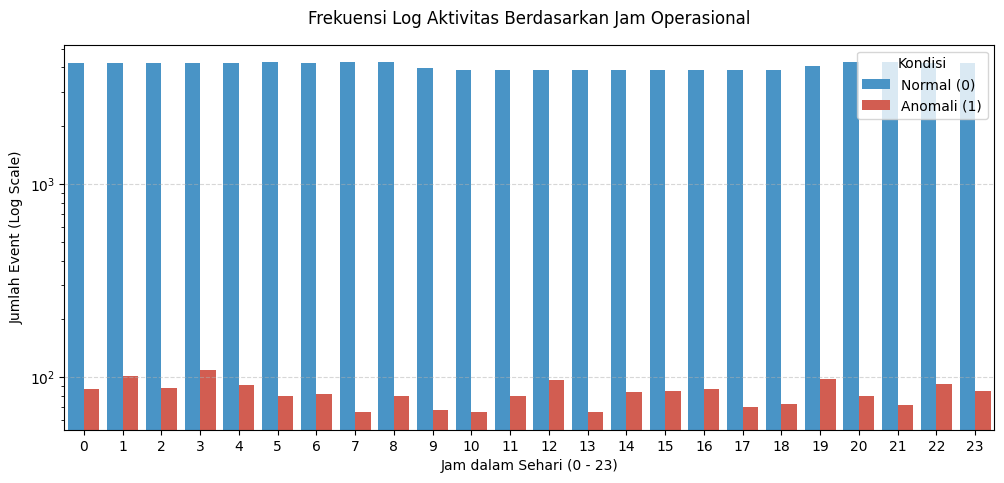

In [36]:
# Buat kolom 'hour' sementara hanya untuk visualisasi
df_events['hour_of_day'] = df_events['event_time'].dt.hour

plt.figure(figsize=(12, 5))
# Gunakan countplot untuk menghitung frekuensi event per jam
ax = sns.countplot(
    data=df_events, 
    x='hour_of_day', 
    hue='target', 
    palette=['#3498db', '#e74c3c']
)

plt.title('Frekuensi Log Aktivitas Berdasarkan Jam Operasional', pad=15)
plt.xlabel('Jam dalam Sehari (0 - 23)')
plt.ylabel('Jumlah Event (Log Scale)')
# Kita wajib gunakan skala log pada sumbu Y karena jumlah anomali sangat kecil (imbalanced data)
plt.yscale('log') 

plt.legend(title='Kondisi', labels=['Normal (0)', 'Anomali (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Hapus kolom sementara agar tidak mengotori dataframe untuk modeling nanti
df_events.drop(columns=['hour_of_day'], inplace=True)

Baik log normal maupun anomali tersebar secara merata di sepanjang 24 jam (0 - 23). Tidak ada jam tertentu yang menunjukkan lonjakan signifikan untuk anomali, yang mengindikasikan bahwa aktivitas mencurigakan dapat terjadi kapan saja sepanjang hari. 

Secara realitas bisnis, aktivitas log normal seharusnya memuncak pada jam kerja (08:00 - 17:00) dan menurun drastis di malam hari. Penyebaran yang sangat rata ini merupakan artefak dari fungsi looping waktu linier pada skrip generator yang berjalan konstan tanpa memedulikan siklus ritme sirkadian (siang-malam) pengguna.

Modeling dan Evaluation

**Pendekatan Multi-Class Classification:**

In [37]:
df_events['target'].value_counts(normalize=True)

target
0    0.98013
1    0.01987
Name: proportion, dtype: float64

In [38]:
label_mapping = {
    'normal': 0,
    'policy_violation': 1,
    'exfiltration_suspected': 2,
    'compromised_account': 3,
    'privilege_abuse': 4
}

In [39]:
df_events['label'] = df_events['label'].map(label_mapping)

In [40]:
# tidak menggunakan fitur 'is_outside_working_hours' dan 'is_weekend' karena tidak memberikan informasi yang signifikan
features = [
    'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action',
    'rolling_bytes_1h',
    'rolling_failed_logins_1h', 'event_count_1h'
]

In [41]:
# Pastikan data sudah terurut waktu
df_events = df_events.sort_values('event_time')

In [42]:
train_frames = []
test_frames = []

In [43]:
# Algoritma Custom Split per Kelas/Label
for label in df_events['label'].unique():
    # Ambil subset data khusus untuk kelas ini
    df_subset = df_events[df_events['label'] == label]
    
    # Hitung batas indeks 80%
    split_index = int(len(df_subset) * 0.8)
    
    # Pisahkan (Fase awal masuk train, fase akhir masuk test)
    # Jika jumlah data sangat sedikit (misal cuma 1 baris), kita paksa masuk train agar model minimal pernah melihatnya
    if len(df_subset) < 2:
        train_frames.append(df_subset)
    else:
        train_frames.append(df_subset.iloc[:split_index])
        test_frames.append(df_subset.iloc[split_index:])

In [44]:
# Gabungkan kembali dan urutkan ulang berdasarkan waktu 
df_train = pd.concat(train_frames).sort_values('event_time')
df_test = pd.concat(test_frames).sort_values('event_time')

In [45]:
X_train = df_train[features]
y_train = df_train['label']
X_test = df_test[features]
y_test = df_test['label']

In [46]:
print(f"Total Data Latih : {len(X_train)} baris")
print(f"Total Data Uji   : {len(X_test)} baris")

print("\n Distribusi Kelas di Data Latih (Awal Serangan):")
print(y_train.value_counts().sort_index())

print("\n Distribusi Kelas di Data Uji (Akhir Serangan):")
print(y_test.value_counts().sort_index())

Total Data Latih : 79999 baris
Total Data Uji   : 20001 baris

 Distribusi Kelas di Data Latih (Awal Serangan):
label
0    78410
1     1545
2       16
3       16
4       12
Name: count, dtype: int64

 Distribusi Kelas di Data Uji (Akhir Serangan):
label
0    19603
1      387
2        4
3        4
4        3
Name: count, dtype: int64


In [47]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)

# Buat kamus (dictionary) yang memetakan Kelas -> Bobot
class_weights_dict = dict(zip(classes, class_weights))

# Petakan bobot tersebut ke seluruh baris sampel target Anda
sample_weights = np.array([class_weights_dict[cls] for cls in y_train])

In [48]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(classes),
    random_state=42,
    n_jobs=-1
)

In [49]:
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [50]:
y_pred_multi = xgb_model.predict(X_test)

In [51]:
target_names_multi = ['Normal (0)', 'Policy Violation (1)', 'Exfiltration (2)', 'Compromised (3)', 'Privilege (4)']
print(classification_report(y_test, y_pred_multi, target_names=target_names_multi))

                      precision    recall  f1-score   support

          Normal (0)       1.00      1.00      1.00     19603
Policy Violation (1)       0.92      0.99      0.95       387
    Exfiltration (2)       1.00      1.00      1.00         4
     Compromised (3)       1.00      1.00      1.00         4
       Privilege (4)       1.00      1.00      1.00         3

            accuracy                           1.00     20001
           macro avg       0.98      1.00      0.99     20001
        weighted avg       1.00      1.00      1.00     20001



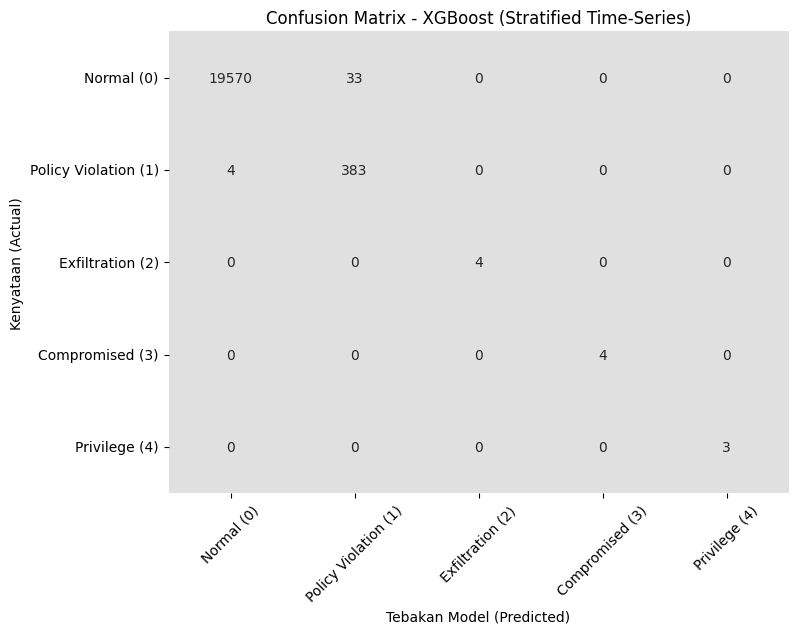

In [52]:
cm_multi = confusion_matrix(y_test, y_pred_multi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap=['#e0e0e0', '#e0e0e0'],
            cbar=False, 
            xticklabels=target_names_multi, 
            yticklabels=target_names_multi)
plt.title('Confusion Matrix - XGBoost (Stratified Time-Series)')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.xticks(rotation=45)
plt.show()

**Pendekatan Binary Classification:**

In [53]:
y_train_bin = (y_train > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

In [54]:
jumlah_normal = (y_train_bin == 0).sum()
jumlah_anomali = (y_train_bin == 1).sum()
rasio_imbalance = jumlah_normal / jumlah_anomali

In [55]:
print(f"Jumlah Data Latih - Normal  : {jumlah_normal}")
print(f"Jumlah Data Latih - Anomali : {jumlah_anomali}")
print(f"Nilai scale_pos_weight      : {rasio_imbalance:.2f}\n")

Jumlah Data Latih - Normal  : 78410
Jumlah Data Latih - Anomali : 1589
Nilai scale_pos_weight      : 49.35



In [56]:
xgb_bin_model = xgb.XGBClassifier(
    n_estimators=100,            # Jumlah iterasi boosting
    max_depth=6,                 # Batasan kedalaman pohon agar tidak overfitting
    learning_rate=0.1,           # Ukuran langkah pembelajaran
    objective='binary:logistic', # Fungsi objektif untuk biner
    scale_pos_weight=rasio_imbalance, # untuk imbalanced data!
    random_state=42,
    n_jobs=-1
)

In [57]:
xgb_bin_model.fit(X_train, y_train_bin)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [58]:
y_pred_bin = xgb_bin_model.predict(X_test)

In [59]:
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Anomali (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     19603
 Anomali (1)       0.93      0.99      0.96       398

    accuracy                           1.00     20001
   macro avg       0.96      0.99      0.98     20001
weighted avg       1.00      1.00      1.00     20001



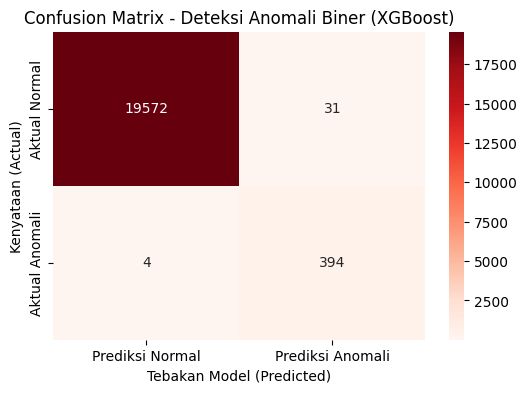

In [60]:
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Prediksi Normal', 'Prediksi Anomali'], 
            yticklabels=['Aktual Normal', 'Aktual Anomali'])
plt.title('Confusion Matrix - Deteksi Anomali Biner (XGBoost)')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.show()

dalam kasus keamanan data, metrik utama yang harus diperhatikan adalah Recall (Sensitivity) untuk kelas Anomali (1). Hal ini karena kita lebih ingin meminimalkan False Negatives (yaitu, tidak mendeteksi serangan yang sebenarnya terjadi) daripada False Positives (yaitu, salah mendeteksi aktivitas normal sebagai serangan).

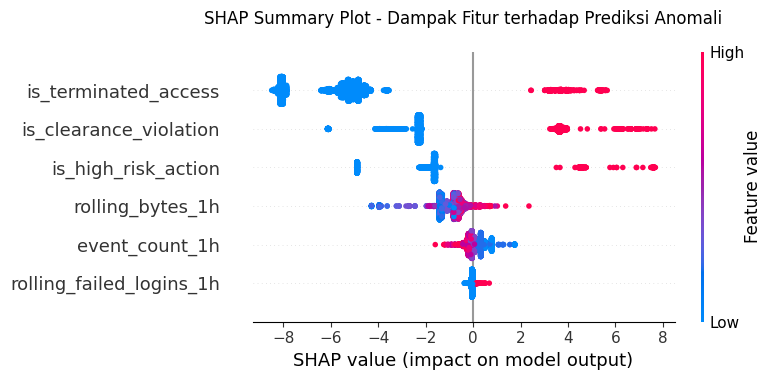

In [61]:
# 1. Inisialisasi explainer khusus untuk model berbasis pohon (XGBoost)
explainer = shap.TreeExplainer(xgb_bin_model)

# 2. Hitung SHAP values (Gunakan sampel jika data terlalu besar agar RAM tidak crash)
# Kita ambil 5000 sampel acak dari X_test untuk visualisasi cepat
X_test_sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 3. Tampilkan Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot - Dampak Fitur terhadap Prediksi Anomali', pad=20)
plt.tight_layout()
plt.show()

model menangkap is_clearanced_violation secara terbalik. Secara logika, jika terjadi pelanggaran hak akses (Warna Merah / High), titiknya harusnya berada di sebelah kanan (mendorong prediksi Anomali). Namun, titik-titik Merah justru berkumpul sangat jauh di sebelah Kiri (negatif -4 hingga -5)! Sebaliknya, titik Biru menumpuk di area tengah/kanan. XGBoost menyimpulkan bahwa "Jika seorang pengguna melakukan pelanggaran hak akses, maka dia adalah pengguna NORMAL". 


Karena data generator Anda memberikan probabilitas acak (uniform) pada pemilihan aset, hampir semua pengguna normal secara konstan menabrak database restricted/confidential. Akibatnya, rasio kejadian pelanggaran akses di kelas Normal (0) jauh lebih masif daripada di kelas Anomali (1). XGBoost, yang murni bekerja berdasarkan matematika statistik, melihat pola ini dan menjadikan pelanggaran akses sebagai signature (ciri khas) dari karyawan normal perusahaan tersebut.

In [73]:
folder_name = '../model/'
os.makedirs(folder_name, exist_ok=True)

In [74]:
json_path = os.path.join(folder_name, 'xgb_anomaly_model_production.json')
xgb_model.save_model(json_path)

In [75]:
json_path_bin = os.path.join(folder_name, 'xgb_anomaly_binary_model_production.json')
xgb_bin_model.save_model(json_path_bin)

# 3. Data Security

Pola 1 (Terminated Access): Ini adalah celah keamanan administratif (Identity and Access Management). Jika pola ini ditemukan, artinya tim HR tidak berkoordinasi dengan tim IT untuk mencabut hak akses (revoke credentials) segera setelah karyawan keluar. Tingkat risiko ini adalah HIGH hingga CRITICAL.

In [62]:
df_pola_1 = df_events[df_events['employee_status'] == 'terminated']
print(f"POLA 1 (Terminated Access) ditemukan : {len(df_pola_1)} insiden.")

POLA 1 (Terminated Access) ditemukan : 5386 insiden.


Pola 2 (Massive Exfiltration): Pencurian kekayaan intelektual atau data nasabah secara masif. Pembatasan ukuran unduhan (bytes_out) menggunakan threshold angka mutlak (> 1.000.000 bytes) di sini untuk mengabaikan aktivitas pengunduhan laporan harian berukuran kecil (KB) yang wajar. Tingkat risiko ini adalah CRITICAL.

In [63]:
df_pola_2 = df_events[
    (df_events['action'] == 'download') & 
    (df_events['data_classification'].isin(['restricted', 'confidential'])) & 
    (df_events['bytes_out'] > 1_000_000)
]
print(f"POLA 2 (Massive Exfiltration) ditemukan: {len(df_pola_2)} insiden.")

POLA 2 (Massive Exfiltration) ditemukan: 20 insiden.


Pola 3 (Privilege Abuse): Modus peretas untuk menanamkan backdoor. Pengubahan hak akses (permission_change) mengindikasikan adanya upaya manipulasi perangkat lunak atau sabotase infrastruktur internal. Tingkat risiko ini adalah HIGH.

In [64]:
df_pola_3 = df_events[df_events['action'].isin(['permission_change', 'delete']) & (df_events['data_classification'].isin(['restricted', 'confidential']))]

print(f"POLA 3 (Privilege Abuse) ditemukan     : {len(df_pola_3)} insiden.")

POLA 3 (Privilege Abuse) ditemukan     : 1523 insiden.


In [65]:
df_pola_4 = df_events[
    (df_events['rolling_failed_logins_1h'] >= 5) &
    (df_events['status'] == 'success')
]

print(f"POLA 4 (Brute Force Success) ditemukan: {len(df_pola_4)} insiden.")

POLA 4 (Brute Force Success) ditemukan: 0 insiden.


In [66]:
df_pola_5 = df_events[df_events['is_clearance_violation'] == 1]
print(f"POLA 5 (Clearance Violation) ditemukan : {len(df_pola_5)} insiden.")

POLA 5 (Clearance Violation) ditemukan : 27867 insiden.


In [67]:
df_pola_6 = df_events[
    (df_events['rolling_failed_logins_1h'] >= 3) &
    (df_events['status'] == 'failed')
]
print(f"POLA 6 (Brute Force Failed) ditemukan: {len(df_pola_6)} insiden.")

POLA 6 (Brute Force Failed) ditemukan: 4 insiden.


In [68]:
def generate_security_alert(row):
    """
    Mengevaluasi satu baris log event dan mengembalikan level risiko (severity).
    Fungsi ini berjalan secara hierarkis (Top-Down): 
    Mengecek kondisi paling kritis terlebih dahulu, lalu turun ke risiko yang lebih rendah.
    """
    
    # ---------------------------------------------------------
    # 1. TIER CRITICAL (Insiden Fatal & Pasti Berbahaya)
    # ---------------------------------------------------------
    # Kondisi A: Karyawan yang sudah dipecat/keluar masih bisa akses sistem
    if row.get('employee_status') == 'terminated':
        return 'CRITICAL'
        
    # Kondisi B: Eksfiltrasi data masif pada aset rahasia (> 1 MB)
    if (row.get('action') == 'download' and 
        row.get('data_classification') in ['restricted', 'confidential'] and 
        row.get('bytes_out', 0) > 1_000_000):
        return 'CRITICAL'

    # ---------------------------------------------------------
    # 2. TIER HIGH (Ancaman Aktif yang Membutuhkan Respon Cepat)
    # ---------------------------------------------------------
    # Kondisi C: Perubahan hak akses atau penghapusan pada kode/database
    if (row.get('action') in ['permission_change', 'delete'] and 
        row.get('data_classification') in ['restricted', 'confidential']):
        return 'HIGH'
        
    # Kondisi D: Indikasi Brute-Force yang BERHASIL 
    # (Banyak gagal sebelumnya, tapi status saat ini success)
    if row.get('rolling_failed_logins_1h', 0) >= 5 and row.get('status') == 'success':
        return 'HIGH'

    # ---------------------------------------------------------
    # 3. TIER MEDIUM (Aktivitas Mencurigakan, Perlu Pemantauan)
    # ---------------------------------------------------------
    # Kondisi E: Pelanggaran batas clearance (Akses tidak sah yang mungkin tidak sengaja)
    is_clearance_violation = (
        row.get('clearance') in ['public', 'internal'] and 
        row.get('data_classification') in ['restricted', 'confidential']
    )
    if is_clearance_violation:
        return 'MEDIUM'
        
    # Kondisi F: Indikasi Brute-Force yang MASIH GAGAL
    if row.get('rolling_failed_logins_1h', 0) >= 3 and row.get('status') == 'failed':
        return 'MEDIUM'

    # ---------------------------------------------------------
    # 4. TIER LOW (Aktivitas Normal atau Kesalahan Operasional Ringan)
    # ---------------------------------------------------------
    # Kondisi G: Gagal login biasa atau error sistem (bukan bagian dari rentetan serangan)
    if row.get('status') == 'failed':
        return 'LOW'
        
    # Default: Segala aktivitas normal lainnya yang berhasil
    return 'LOW'

In [69]:
df_events['alert_level'] = df_events.apply(generate_security_alert, axis=1)

alert_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
df_events['alert_level'] = pd.Categorical(df_events['alert_level'], categories=alert_order, ordered=True)

In [70]:
distribusi_alert = df_events['alert_level'].value_counts().sort_index()
distribusi_alert

alert_level
CRITICAL     5386
HIGH         1447
MEDIUM      26072
LOW         67095
Name: count, dtype: int64

In [71]:
print("\nDistribusi Tingkat Risiko (Alert Levels):")
df_alert_summary = pd.DataFrame({
    'Jumlah Insiden': distribusi_alert,
    'Persentase (%)': (distribusi_alert / len(df_events) * 100).round(2)
})
display(df_alert_summary)


Distribusi Tingkat Risiko (Alert Levels):


,Jumlah Insiden,Persentase (%)
alert_level,,
CRITICAL,5386,5.39
HIGH,1447,1.45
MEDIUM,26072,26.07
LOW,67095,67.10
